# TSP: A Practical $\mathbb{Z}^n$ Optimisation Example

In the previous notebook we introduced $h$-means as a practical $\mathbb{R}^n$ problem. The **Travelling Salesman Problem (TSP)** plays the same role for $\mathbb{Z}^n$: it is a real combinatorial problem, not a synthetic benchmark.

**Problem:** given $n$ cities with known pairwise distances, find the shortest tour that visits every city exactly once and returns to the start.

TSP belongs to a different domain than De Jong 1 or Rastrigin — the solution is a *permutation*, not a real vector. The central question of this notebook is: **how do we encode a permutation as an integer vector so that the heuristic framework works unchanged?**

This notebook covers:
1. The objective function and grid instance
2. Solution encoding — why the Lehmer code is efficient
3. FSA benchmark
4. Greedy initialisation — from pure random to pure nearest-neighbour, and the sweet spot between them

In [1]:
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from objfun_tsp import TSPGrid
from heur_fsa import FastSimulatedAnnealing
from heur_aux import CauchyMutation, Correction

## 1. The Objective Function

`TSPGrid(par_a, par_b)` places `par_a × par_b` cities on a regular integer grid and pre-computes the full distance matrix. The optimal tour length `fstar` is known analytically for this instance:

$$f^* = n + (n \bmod 2) \cdot (\sqrt{2} - 1)$$

i.e. a snake-like path using $n-1$ unit steps and one diagonal step when $n$ is odd.

In [3]:
tsp = TSPGrid(3, 3)

print(f'Cities          : {tsp.n}')
print(f'Solution dim    : {len(tsp.a)}  (n-1, first city is fixed)')
print(f'f*              : {tsp.fstar:.6f}')
print(f'Domain lower    : {tsp.a}')
print(f'Domain upper    : {tsp.b}')
print()
print('Distance matrix (first 4×4):')
print(tsp.dist[:4, :4].round(3))

Cities          : 9
Solution dim    : 8  (n-1, first city is fixed)
f*              : 9.414214
Domain lower    : [0 0 0 0 0 0 0 0]
Domain upper    : [7 6 5 4 3 2 1 0]

Distance matrix (first 4×4):
[[0.    1.    2.    1.   ]
 [1.    0.    1.    1.414]
 [2.    1.    0.    2.236]
 [1.    1.414 2.236 0.   ]]


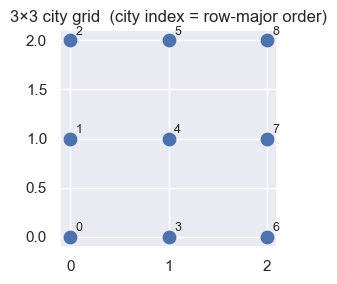

In [4]:
def plot_tour(tsp, cx, ax=None, title=None):
    """Plot the city grid and a tour given as a decoded (ordered) city sequence."""
    coords = tsp.grid
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    tour = np.append(cx, cx[0])   # close the loop
    ax.plot(coords[tour, 0], coords[tour, 1], 'o-', markersize=8)
    for k in range(tsp.n):
        ax.annotate(str(k), coords[k], textcoords='offset points', xytext=(4, 4), fontsize=9)
    ax.set_title(title or f'Tour length = {tsp.tour_dist(cx):.4f}')
    ax.set_aspect('equal')
    return ax

# Show the city layout (no tour)
_, ax = plt.subplots(figsize=(3, 3))
ax.scatter(tsp.grid[:, 0], tsp.grid[:, 1], s=80, zorder=3)
for k in range(tsp.n):
    ax.annotate(str(k), tsp.grid[k], textcoords='offset points', xytext=(4, 4), fontsize=9)
ax.set_title('3×3 city grid  (city index = row-major order)')
ax.set_aspect('equal')
plt.tight_layout()

## 2. Solution Encoding

### The naive approach and why it fails

The obvious encoding is a permutation of city indices: `[0, 3, 7, 1, ...]`. But this breaks the heuristic framework:
- The domain would be $[0, n-1]^n$, containing $n^n$ integer vectors
- Only $n!$ of these are valid permutations (no repeated cities)
- A Cauchy mutation almost certainly produces an invalid tour — repeated or missing cities
- A repair operator is needed, which complicates the framework and wastes evaluations

### The Lehmer encoding (factoradic)

Instead, encode the *choice* made at each step:

> `x[k]` = index of the chosen city in the list of **remaining** unvisited cities at step $k$

This means:
- `x[0]` ∈ $[0, n-2]$ — choose 1st city from $n-1$ remaining
- `x[1]` ∈ $[0, n-3]$ — choose 2nd city from $n-2$ remaining
- ...
- `x[n-2]` ∈ $[0, 0]$ — last city is forced

The domain bounds are non-uniform: `a = [0, 0, ..., 0]`, `b = [n-2, n-3, ..., 0]`.

**Key property:** every integer vector in this domain decodes to a valid tour. No repair needed — the standard `Correction` clipping always stays within valid ranges, and every clipped vector is a legal tour.

In [5]:
# Demonstrate encoding and decoding with a fixed seed
rng = np.random.default_rng(0)
x = tsp.generate_point(rng)
cx = tsp.decode(x)

print(f'Encoded  x  : {x}   (shape: {x.shape}, dtype: {x.dtype})')
print(f'Decoded  cx : {cx}  (ordered city visit sequence)')
print(f'Tour length : {tsp.tour_dist(cx):.4f}  (f* = {tsp.fstar:.4f})')
print()

# verify every city appears exactly once
assert sorted(cx) == list(range(tsp.n)), "decode produced an invalid tour!"
print('Validity check passed — all cities visited exactly once.')

Encoded  x  : [4 1 1 4 3 2 0 0]   (shape: (8,), dtype: int64)
Decoded  cx : [0 5 2 3 8 7 6 1 4]  (ordered city visit sequence)
Tour length : 14.3585  (f* = 9.4142)

Validity check passed — all cities visited exactly once.


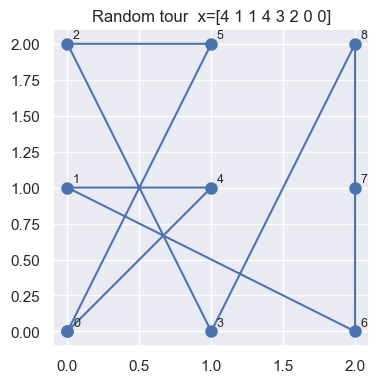

In [6]:
plot_tour(tsp, cx, title=f'Random tour  x={x}')
plt.tight_layout()

## 3. FSA Benchmark

We run FSA on `TSPGrid(3, 3)` using parameters informed by prior analysis: `T0=1`, `n0=5`, `alpha=2`, `r=0.75`. All runs use a fixed seed for reproducibility.

In [7]:
NUM_RUNS = 1000
MAXEVAL  = 1000

def run_fsa(tsp, num_runs, maxeval, T0, n0, alpha, r, label):
    records = []
    for seed in tqdm(range(num_runs), desc=label, leave=False):
        mut = CauchyMutation(r=r, correction=Correction(tsp))
        res = FastSimulatedAnnealing(tsp, maxeval=maxeval, T0=T0, n0=n0, alpha=alpha,
                                     mutation=mut, seed=seed).search()
        records.append({'label': label, 'seed': seed,
                        'best_y': res['best_y'], 'neval': res['neval'],
                        'success': res['success'], 'best_x': res['best_x']})
    return pd.DataFrame(records)

def stats(df):
    rel = df['success'].mean()
    mne = df.loc[df['success'], 'neval'].mean() if rel > 0 else float('nan')
    feo = mne / rel if rel > 0 else float('nan')
    return pd.Series({'REL': rel, 'MNE': mne, 'FEO': feo})

df_base = run_fsa(tsp, NUM_RUNS, MAXEVAL, T0=1, n0=5, alpha=2, r=0.75, label='FSA baseline')
print(stats(df_base).to_string())

FSA baseline:   0%|          | 0/1000 [00:00<?, ?it/s]

REL      0.823000
MNE    259.351154
FEO    315.128985


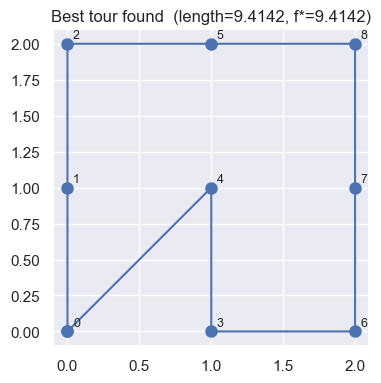

In [8]:
# Visualise the best tour found across all runs
best_row = df_base.loc[df_base['best_y'].idxmin()]
cx_best = tsp.decode(best_row['best_x'])
plot_tour(tsp, cx_best, title=f'Best tour found  (length={best_row["best_y"]:.4f}, f*={tsp.fstar:.4f})')
plt.tight_layout()

## 4. Greedy Initialisation

### Motivation

FSA starts every run from a random solution generated by `generate_point`. That random tour is typically far from optimal — the heuristic then spends many evaluations just escaping the initial bad region.

A classical alternative is the **nearest-neighbour greedy heuristic**: start from city 0, always move to the closest unvisited city. The result is a decent tour in O(n²) time, and it can be encoded directly in the Lehmer representation.

### The `greediness` parameter

`TSPGrid` accepts a `greediness ∈ [0, 1]` parameter that controls initial-point generation:

| `greediness` | Behaviour |
|---|---|
| `0.0` | pure random — current default |
| `1.0` | pure nearest-neighbour greedy |
| `g ∈ (0, 1)` | at each step, pick nearest with prob `g`, random with prob `1-g` |

At `g=0` this is provably equivalent to the original random generator (same uniform distribution over the domain).

### Why might pure greedy (`g=1`) not be optimal for FSA?

A pure greedy generator always produces the **same** initial tour (it is deterministic). All FSA runs start from the same point, so they explore similar regions of the search space. Some diversity in the starting point helps FSA cover the landscape — a small random component reintroduces that diversity.

We expect a **sweet spot** somewhere between `g=0` and `g=1`.

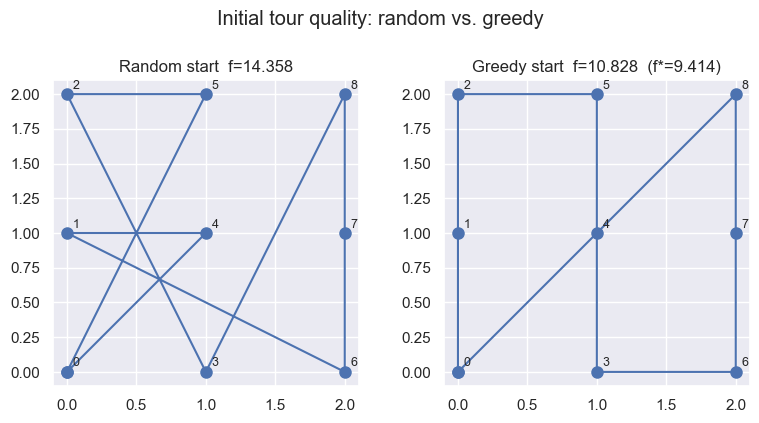

In [9]:
# Show initial tour quality: random vs. greedy (seed=0 for both)
rng = np.random.default_rng(0)
x_rand  = TSPGrid(3, 3, greediness=0.0).generate_point(rng)
rng = np.random.default_rng(0)
x_greedy = TSPGrid(3, 3, greediness=1.0).generate_point(rng)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_tour(tsp, tsp.decode(x_rand),   ax=axes[0], title=f'Random start  f={tsp.evaluate(x_rand):.3f}')
plot_tour(tsp, tsp.decode(x_greedy), ax=axes[1], title=f'Greedy start  f={tsp.evaluate(x_greedy):.3f}  (f*={tsp.fstar:.3f})')
plt.suptitle('Initial tour quality: random vs. greedy', y=1.02)
plt.tight_layout()

In [10]:
GREEDINESS_VALUES = [0.0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]

records = []
for g in GREEDINESS_VALUES:
    tsp_g = TSPGrid(3, 3, greediness=g)
    for seed in tqdm(range(NUM_RUNS), desc=f'greediness={g}', leave=False):
        mut = CauchyMutation(r=0.75, correction=Correction(tsp_g))
        res = FastSimulatedAnnealing(tsp_g, maxeval=MAXEVAL, T0=1, n0=5, alpha=2,
                                     mutation=mut, seed=seed).search()
        records.append({'greediness': g, 'seed': seed,
                        'neval': res['neval'], 'success': res['success']})

df_greedy = pd.DataFrame(records)
sweep = df_greedy.groupby('greediness').apply(stats).reset_index()
print(sweep.to_string(index=False))

greediness=0.0:   0%|          | 0/1000 [00:00<?, ?it/s]

greediness=0.25:   0%|          | 0/1000 [00:00<?, ?it/s]

greediness=0.5:   0%|          | 0/1000 [00:00<?, ?it/s]

greediness=0.75:   0%|          | 0/1000 [00:00<?, ?it/s]

greediness=0.9:   0%|          | 0/1000 [00:00<?, ?it/s]

greediness=0.95:   0%|          | 0/1000 [00:00<?, ?it/s]

greediness=0.99:   0%|          | 0/1000 [00:00<?, ?it/s]

greediness=1.0:   0%|          | 0/1000 [00:00<?, ?it/s]

 greediness   REL        MNE        FEO
       0.00 0.823 259.351154 315.128985
       0.25 0.840 238.128571 283.486395
       0.50 0.837 226.365591 270.448735
       0.75 0.850 216.771765 255.025606
       0.90 0.890 197.189888 221.561672
       0.95 0.903 198.393134 219.704467
       0.99 0.910 205.320879 225.627340
       1.00 0.907 201.478501 222.137266


/var/folders/y7/jjxwxthj1yn61lfnqjmc9xy00000gn/T/ipykernel_19719/1906950516.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sweep = df_greedy.groupby('greediness').apply(stats).reset_index()


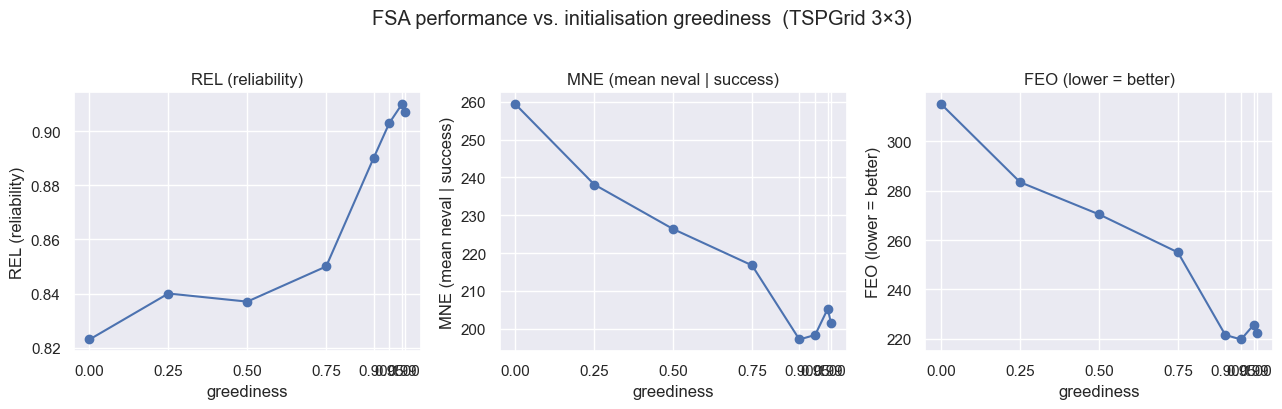

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, ylabel in zip(axes,
                               ['REL', 'MNE', 'FEO'],
                               ['REL (reliability)', 'MNE (mean neval | success)', 'FEO (lower = better)']):
    ax.plot(sweep['greediness'], sweep[metric], marker='o')
    ax.set_xlabel('greediness')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticks(GREEDINESS_VALUES)

plt.suptitle('FSA performance vs. initialisation greediness  (TSPGrid 3×3)', y=1.02)
plt.tight_layout()

### Sweet spot on the 3×3 instance — and why we expect it to be more pronounced on 4×4

The 3×3 results already show a mild sweet spot: REL peaks at `g=0.99` and FEO is lowest at `g=0.95`, while pure greedy (`g=1.0`) is very slightly outperformed on both metrics. This confirms the hypothesis — pure greedy always starts from the **same** tour, so all 1 000 FSA runs explore similar regions of the search space.

The effect is subtle because the 3×3 landscape is small: with city 0 fixed, there are only $8! = 40\,320$ legal tours and a budget of 1 000 evaluations covers the neighbourhood well regardless of starting quality.

On a **4×4 grid (16 cities)** the landscape is vastly larger ($15! \approx 1.3 \times 10^{12}$ tours), the budget covers only a tiny fraction, and the starting point matters much more — the diversity-vs-quality tradeoff should be clearly visible.

4×4  greediness=0.0:   0%|          | 0/1000 [00:00<?, ?it/s]

4×4  greediness=0.25:   0%|          | 0/1000 [00:00<?, ?it/s]

4×4  greediness=0.5:   0%|          | 0/1000 [00:00<?, ?it/s]

4×4  greediness=0.75:   0%|          | 0/1000 [00:00<?, ?it/s]

4×4  greediness=0.9:   0%|          | 0/1000 [00:00<?, ?it/s]

4×4  greediness=0.95:   0%|          | 0/1000 [00:00<?, ?it/s]

4×4  greediness=0.99:   0%|          | 0/1000 [00:00<?, ?it/s]

4×4  greediness=1.0:   0%|          | 0/1000 [00:00<?, ?it/s]

 greediness   REL         MNE          FEO
       0.00 0.058 4924.517241 84905.469679
       0.25 0.061 4780.590164 78370.330556
       0.50 0.057 4845.175439 85003.077870
       0.75 0.058 4691.568966 80889.120095
       0.90 0.085 4662.258824 54850.103806
       0.95 0.075 4851.800000 64690.666667
       0.99 0.074 4999.027027 67554.419284
       1.00 0.070 4885.671429 69795.306122


/var/folders/y7/jjxwxthj1yn61lfnqjmc9xy00000gn/T/ipykernel_19719/3560194237.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sweep_4x4 = df_4x4.groupby('greediness').apply(stats).reset_index()


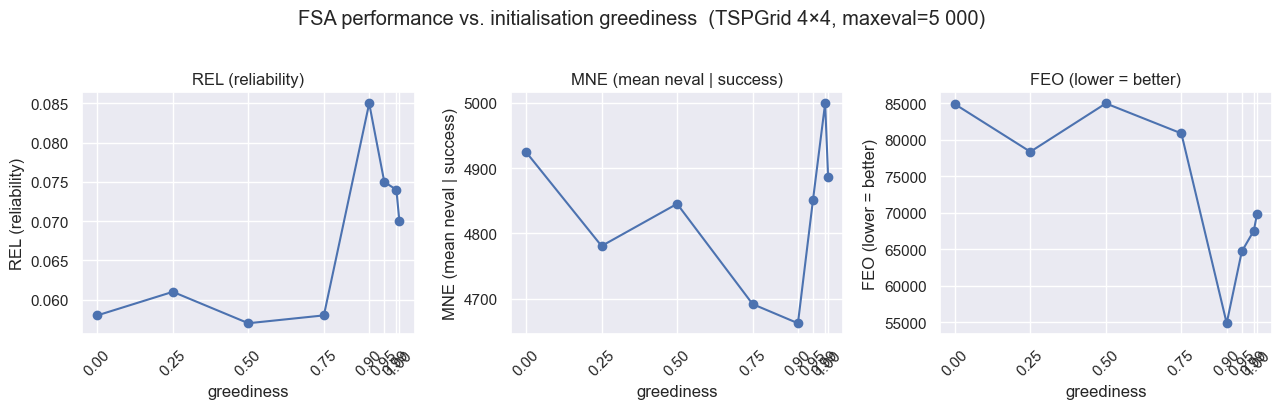

In [12]:
NUM_RUNS_4x4 = 1_000
MAXEVAL_4x4  = 10_000   # larger budget for the harder instance

records_4x4 = []
for g in GREEDINESS_VALUES:
    tsp_g = TSPGrid(4, 4, greediness=g)
    for seed in tqdm(range(NUM_RUNS_4x4), desc=f'4×4  greediness={g}', leave=False):
        mut = CauchyMutation(r=0.1, correction=Correction(tsp_g))
        res = FastSimulatedAnnealing(tsp_g, maxeval=MAXEVAL_4x4, T0=1, n0=500, alpha=2,
                                     mutation=mut, seed=seed).search()
        records_4x4.append({'greediness': g, 'seed': seed,
                             'neval': res['neval'], 'success': res['success']})

df_4x4 = pd.DataFrame(records_4x4)
sweep_4x4 = df_4x4.groupby('greediness').apply(stats).reset_index()
print(sweep_4x4.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, ylabel in zip(axes,
                               ['REL', 'MNE', 'FEO'],
                               ['REL (reliability)', 'MNE (mean neval | success)', 'FEO (lower = better)']):
    ax.plot(sweep_4x4['greediness'], sweep_4x4[metric], marker='o')
    ax.set_xlabel('greediness')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticks(GREEDINESS_VALUES)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('FSA performance vs. initialisation greediness  (TSPGrid 4×4, maxeval=5 000)', y=1.02)
plt.tight_layout()

The 4×4 results confirm the expected pattern. The sweet spot lands at **`g=0.90`** (REL = 0.085, FEO ≈ 54 850) — clearly outperforming both pure random (`g=0`, REL = 0.058) and pure greedy (`g=1.0`, REL = 0.070). Notably, the optimal greediness has shifted **left** compared to the 3×3 case (which peaked at 0.95–0.99): on a harder instance, diversity matters more, so a larger random component is beneficial. Overall reliability is low (< 10%) even at the sweet spot, reflecting the vastly larger search space of the 16-city instance.

## Summary

### Why TSP?

| Property | De Jong 1 | Rastrigin | $h$-means | TSP |
|---|---|---|---|---|
| Domain | $\mathbb{R}^n$ | $\mathbb{R}^n$ | $\mathbb{R}^{h \cdot d}$ | $\mathbb{Z}^{n-1}$ |
| $f^*$ known analytically | yes | yes | no | **yes** (grid instance) |
| Practical meaning | none | none | cluster recovery | route planning |
| Landscape | smooth | regular traps | data-dependent | complex, combinatorial |

### The encoding is the key design decision

The Lehmer encoding maps every integer vector in the domain to a valid permutation, so no repair operator is needed. The non-uniform domain bounds (`b = [n-2, n-3, ..., 0]`) are handled automatically by the existing `Correction` class. The heuristic framework required **zero modification**.

### Greedy initialisation

Purely random starting points give FSA a harder job. A partially greedy generator (nearest-neighbour with some randomness) improves the starting position while retaining diversity across runs.

On the 3×3 instance the sweet spot is already visible but mild (REL peaks at `g=0.99`, FEO at `g=0.95`) — the landscape is small enough that the budget covers it well regardless of where FSA starts. On the 4×4 instance, where only a tiny fraction of $15! \approx 1.3 \times 10^{12}$ tours can be visited within budget, the tradeoff between starting quality and run diversity becomes the dominant factor.

### Assignments
- The greedy tour from `g=1.0` is always the same. What does this mean for REL? Should you ever use `g=1.0` in practice?
- Try `MirrorCorrection` or `ExtensionCorrection` instead of `Correction`. Does the boundary strategy matter for this domain?
- Repeat the greediness sweep on `TSPGrid(5, 5)`. Does the sweet spot shift further toward `g=0` as the instance grows?
- Have a look at the neighbourhood defined for TSP — can you improve it, and make the Shoot & Go heuristic competitive?
  1. Analyze why SG with the current neighborhood is likely to fail
  2. Implement 2-opt via decode → move → re-encode
  3. Run SG with 2-opt and compare to FSA baseline (REL/MNE/FEO) 
  4. Observe: SG should converge much faster per run but get stuck in 2-opt local optima — combine with random restarts    